In [1]:
%matplotlib inline

import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib import rc, rcParams
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Make use of TeX\ufeff
rc('text',usetex=True)
# Change all fonts to 'Computer Modern'
rc('font',**{'size':14, 'family':'serif','serif':['Times New Roman']})
rc('xtick.major', size=5, pad=7)
rc('xtick', labelsize=15)
rc('ytick.major', size=5, pad=7)
rc('ytick', labelsize=15)

# uses matplotlib-label-lines, see for example https://github.com/cphyc/matplotlib-label-lines
from labellines import labelLine, labelLines

# this needs to point to the folder where darkelf.py is stored
work_dir = os.getcwd()
sys.path.append(work_dir+"/..")
plotdir=work_dir+"/plots/"

from darkelf import darkelf, targets

In [3]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/R

# From Example Notebook

In [40]:
targets.list_all()

	 data\Al
	 data\Al2O3
	 data\C
	 data\GaAs
	 data\GaN
	 data\Ge
	 data\Si
	 data\SiC
	 data\SiO2
	 data\Ta
	 data\Xe
	 data\ZnS


In [41]:
targets.files('GaAs')

Available configuration files: 
	 GaAs\GaAs.yaml
 
Available data for epsilon: 
	 GaAs\GaAs_epsphonon_data10K.dat
	 GaAs\GaAs_mermin.dat
 
Available data for phonon (partial) density of states: 
	 GaAs\As_pDoS.dat
	 GaAs\Ga_pDoS.dat
 
Available data for Fn(omega) functions: 
	 GaAs\As_Fn.dat
	 GaAs\Ga_Fn.dat
 
Available data for form factors: 
	 GaAs\As_atomic_Zion.dat
	 GaAs\As_Zion.dat
	 GaAs\Ga_atomic_Zion.dat
	 GaAs\Ga_Zion.dat


In [42]:
mX=1.0e8 # specify the dark matter mass

# create an object for each target material. This reads in precalculated tables for the ELF and interpolates them
# For Si and Ge, we will create a separate darkelf object with the Mermin and GPAW grids, to compare both calculations. 
Si_gpaw = darkelf(target='Si',mX=mX,filename="Si_gpaw_withLFE.dat")
Si = darkelf(target='Si',mX=mX,filename="Si_mermin.dat")

Ge_gpaw = darkelf(target='Ge',mX=mX,filename="Ge_gpaw_withLFE.dat")
Ge = darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat")

GaAs = darkelf(target='GaAs',mX=mX,filename="GaAs_mermin.dat")

GaN = darkelf(target='GaN',mX=mX,filename="GaN_mermin.dat")

Al = darkelf(target='Al',mX=mX,filename="Al_mermin.dat")

SiO2 = darkelf(target='SiO2',mX=mX,filename="SiO2_mermin.dat")

ZnS = darkelf(target='ZnS',mX=mX,filename="ZnS_mermin.dat")

# example on how to load the ELF for the phonon regime
Al2O3 = darkelf(target='Al2O3',mX=mX,filename="Al2O3_mermin.dat",phonon_filename="Al2O3_epsphonon_o.dat") 

target_list=[Al,Al2O3,GaAs,GaN,Ge,Si,SiO2,ZnS]

 .... Loading files for Si
Loaded Si_gpaw_withLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, http

KeyboardInterrupt: 

In [ ]:
Ge_gpaw.e0+Ge_gpaw.E_gap

3.57

In [ ]:
?Si.update_params

Signature:
Si.update_params(
    mX=0,
    delta=0,
    setdelta=False,
    mMed=-1,
    vesckms=0,
    v0kms=0,
    vekms=0,
    mediator='',
    q0=0.0,
    SD_op="A'",
    gp_gn_ratio_val=1,
    set_gp_gn_ratio_val=False,
    gp_gn_ratio='g_n/g_p',
)
Docstring:
Function to update dark matter parameters used in the class.
If the value is set to zero or not set in the arguments, then that means no changes.

Inputs
------
mX: float
    Mass in [eV]
delta: float
    Inelastic splitting in DM states [eV]
    Must set setdelta=True in this case to get delta=0
    Currently just used for DM-electron scattering
mMed: float
    DM-SM mediator mass in eV
    If zero or not set, then default is mMed = 100*mX (massive mediator for NR scattering)
mediator: string
    options: "massless" or "massive"
    setting mMed overrides this option
vesckms: float
    Set vesc in units of km/s
v0kms: float
    Set vesc in units of km/s
vekms: float
    Set vesc in units of km/s
mediator: string 'massive' or

In [ ]:
Si.update_params(mX=1e7, mediator='massless') # set massless mediator limit
Si.DM_params()
print("-------")
Si.update_params(mX=1e6, mMed=10.) # set specific mediator mass. This takes precendent over the "mediator" flag.
Si.DM_params()

mX = 10000000.0 eV
mMed = 0.0 eV
delta = 0.0 eV
-------
mX = 1000000.0 eV
mMed = 10.0 eV
delta = 0.0 eV


In [ ]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/R

# def get_limit(target,mX,vs={"v0kms":220,"vesckms":11},threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
#     target.update_params(mX=mX,mediator=mediator,vesckms=vs["vesckms"],v0kms=vs["v0kms"])
#     R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut)
#     if R==0.0:
#         return 1.0
#     else:
#         return 3.0*1.0e-38/R

In [ ]:
masslist=np.logspace(6,9,50)
kcut=1.2e4 # restrict phase space for massive mediator

# target_list=[Ge,Si,SiO2]
target_list=[Si]

lim_massless=[]
lim_massive=[]
for target in target_list:
    print(target.target)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    
lim_massless=np.array(lim_massless) 
lim_massive=np.array(lim_massive)

Si


In [ ]:
lim_massless

array([[1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        4.64581226e-38, 3.64381750e-39, 9.02070351e-40, 3.62068604e-40,
        1.91457781e-40, 1.20846578e-40, 8.66197674e-41, 6.81633835e-41,
        5.74421989e-41, 5.13592484e-41, 4.79929398e-41, 4.63898068e-41,
        4.61487261e-41, 4.69828328e-41, 4.87611719e-41, 5.13857759e-41,
        5.48889291e-41, 5.92602572e-41, 6.45634406e-41, 7.08735147e-41,
        7.83969122e-41, 8.71393405e-41, 9.73896364e-41, 1.09290256e-40,
        1.23081752e-40, 1.38979439e-40, 1.57395130e-40, 1.78653815e-40,
        2.03175937e-40, 2.31448148e-40, 2.64034563e-40, 3.01580033e-40,
        3.44834098e-40, 3.94654904e-40, 4.52038322e-40, 5.18124035e-40,
        5.94228522e-40, 6.81866458e-40, 7.82782339e-40, 8.98984921e-40,
        1.03278796e-39, 1.18685478e-39, 1.36499245e-39, 1.56936578e-39,
        1.80468359e-39, 2.07563265e-39]])

[Text(4.0, 1.8110507445682197e-41, 'Ge')]

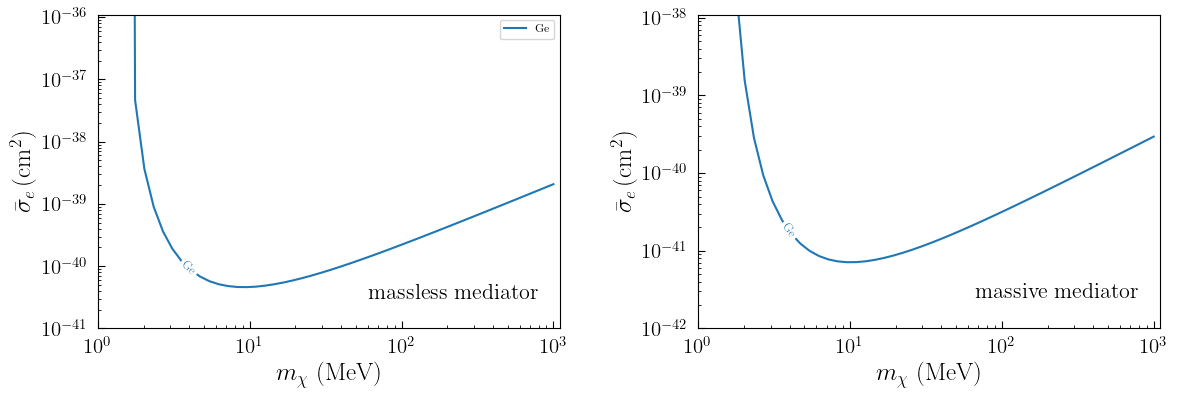

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(12,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
targetlabels=["Ge"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(target_list)):
    axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
    axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs[0].set_xscale("log")   
axs[0].set_yscale("log")
axs[0].set_xlim([1e0,1.1e3])
axs[0].set_ylim([1e-41,1.1e-36])
axs[0].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
axs[0].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs[0].tick_params(direction="in",which="both")
axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[1].set_xscale("log")   
axs[1].set_yscale("log")  
axs[1].set_xlim([1e0,1.1e3])
axs[1].set_ylim([1e-42,1.1e-38])
axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs[1].tick_params(direction="in",which="both")
axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[0].legend(ncol=2,fontsize=8)

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs[0].get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs[1].get_lines()
labelLines(lines,fontsize=9,xvals=[4,60,20,8,20,5,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# fig.savefig(plotdir+"darkelf_electron_6.pdf",bbox_inches='tight')

# V scan

In [ ]:
mX=1.0e8 # specify the dark matter mass

# create an object for each target material. This reads in precalculated tables for the ELF and interpolates them
# For Si and Ge, we will create a separate darkelf object with the Mermin and GPAW grids, to compare both calculations. 
Si_gpaw = darkelf(target='Si',mX=mX,filename="Si_gpaw_withLFE.dat")
Si = darkelf(target='Si',mX=mX,filename="Si_mermin.dat")

Ge_gpaw = darkelf(target='Ge',mX=mX,filename="Ge_gpaw_withLFE.dat")
Ge = darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat")

GaAs = darkelf(target='GaAs',mX=mX,filename="GaAs_mermin.dat")

GaN = darkelf(target='GaN',mX=mX,filename="GaN_mermin.dat")

Al = darkelf(target='Al',mX=mX,filename="Al_mermin.dat")

SiO2 = darkelf(target='SiO2',mX=mX,filename="SiO2_mermin.dat")

ZnS = darkelf(target='ZnS',mX=mX,filename="ZnS_mermin.dat")

# example on how to load the ELF for the phonon regime
Al2O3 = darkelf(target='Al2O3',mX=mX,filename="Al2O3_mermin.dat",phonon_filename="Al2O3_epsphonon_o.dat") 

target_list=[Al,Al2O3,GaAs,GaN,Ge,Si,SiO2,ZnS]

 .... Loading files for Si
Loaded Si_gpaw_withLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, http

KeyboardInterrupt: 

In [ ]:
# def get_limit_w_vs(target,mX,vs={"v0kms":220,"vesckms":11},threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
#     target.update_params(mX=mX,mediator=mediator,vesckms=vs["vesckms"],v0kms=vs["v0kms"])
#     R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut)
#     if R==0.0:
#         return 1.0
#     else:
#         return 3.0*1.0e-38/R

def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/R

In [47]:
print(np.sqrt(43**2 + 11**2))
print(sqrtmrat * 220)
sqrtmrat * np.sqrt(43**2 + 11**2)

44.384682042344295
22000.0


np.float64(4438.468204234429)

In [58]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 220,"vesckms":500,"vekms":240,"vdist":"halo","fD":0.01},\
        #    {"v0kms":sqrtmrat * 20,"vesckms":11,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
             {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01}] # all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

Ge
Ge
Ge


NameError: name 'Si' is not defined

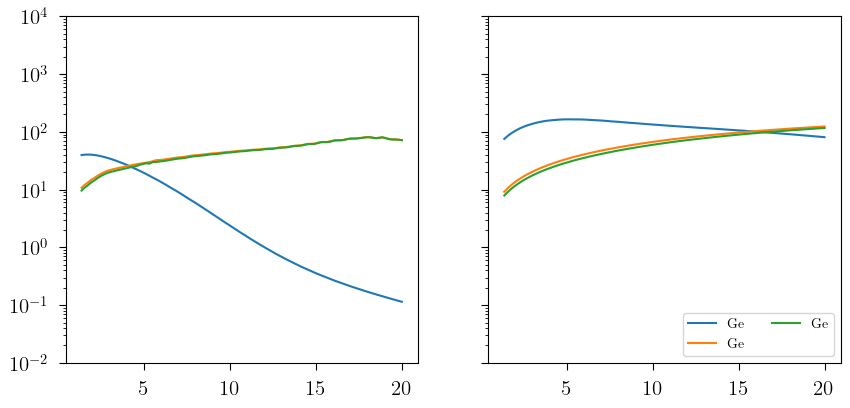

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(10, 4.5),sharey=True)

cmap = plt.get_cmap('Spectral')
colors = cmap(np.linspace(0.0,1.0,8))

for target in target_list:
    print(target.target)
    olist=np.linspace(2.0*target.E_gap,20.0,100)
    
    # massless mediator
    target.update_params(mX=1e8, mediator='massless')
    Rlist=target.dRdomega_electron(olist,method="grid",sigmae=1e-38, kcut=0, withscreening=True,vdist=target.vdist)
    axs[0].plot(olist,Rlist,label=target.target)
    
    # massive mediator
    target.update_params(mX=1e8, mediator='massive')
    Rlist=target.dRdomega_electron(olist,method="grid",sigmae=1e-38, kcut=0, withscreening=True,vdist=target.vdist)
    axs[1].plot(olist,Rlist,label=target.target)
    
    
axs[0].set_yscale("log")
axs[1].legend(ncol=2,fontsize=10,loc="lower right")
axs[0].set_ylim([1e-2,1e4])

axs[0].text(0,4e3,"$m_X=$"+str(int(Si.mX*1e-6))+" MeV",fontsize=14,backgroundcolor="white")
axs[0].text(0,1.5e3,r"$\bar \sigma_e=10^{-38}\,\mathrm{cm}^{2}$",fontsize=14,backgroundcolor="white")
axs[0].text(19.5,4e3,r"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[1].text(0,4e3,"$m_X=$"+str(int(Si.mX*1e-6))+" MeV",fontsize=14,backgroundcolor="white")
axs[1].text(0,1.5e3,r"$\bar \sigma_e=10^{-38}\,\mathrm{cm}^{2}$",fontsize=14,backgroundcolor="white")
axs[1].text(19.5,4e3,r"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[0].set_xlabel("$\omega$ [eV]")
axs[1].set_xlabel("$\omega$ [eV]")
axs[0].set_ylabel("$dR/d\omega\, [1/kg/yr/eV]$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.2)


[Text(4.0, 1.0000000000000164, 'Ge - halo, non-aDM'),
 Text(100.0, 2.1911005202919533e-40, 'Ge - halo, aDM'),
 Text(20.0, 8.513601732501325e-42, 'Ge - halo, max charged'),
 Text(8.0, 9.478947848117224e-43, 'Ge - disk, sun lots'),
 Text(1.5, 1.2121586234277977e-43, 'Ge - disk, sun little'),
 Text(10.0, 1.209209185515157e-42, 'Ge - disk, little both')]

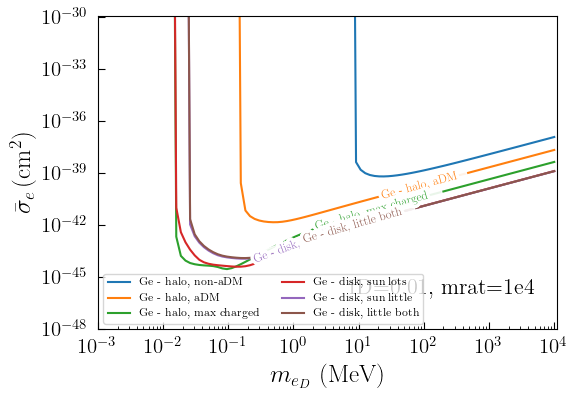

In [50]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist * 1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e-3,1.1e4])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (MeV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e3,1e-46,"fD=0.01, mrat=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8)
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
# lines = axs[1].get_lines()
# labelLines(lines,fontsize=9,xvals=[4,60,20,8,20,5,100,10],zorder=2.5,
#            ha='center',va='center',align=True,bbox=props)

# fig.savefig(plotdir+"darkelf_electron_6.pdf",bbox_inches='tight')

[Text(9000000100.0, 3.0231218833571885e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 1.978898117778106e-38, 'Ge - halo, aDM'),
 Text(9000000100.0, 4.0253756692391014e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.2014916460415585e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.1780465275495896e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.1862684906815596e-39, 'Ge - disk, little both')]

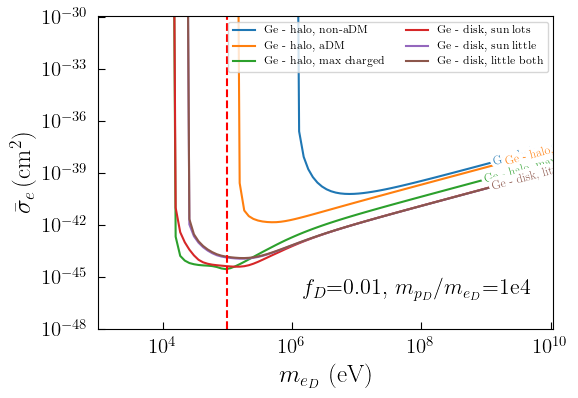

In [62]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# V scan with corrected ve

In [12]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 220,"vesckms":500,"vekms":240,"vdist":"halo","fD":0.01},\
        #    {"v0kms":sqrtmrat * 20,"vesckms":11,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 220,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 220,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
             {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01}] # all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child7), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 3.0231218833571885e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 9.124290737612587e-32, 'Ge - halo, aDM'),
 Text(9000000100.0, 5.315111757656385e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.2779058666495736e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.4263038576053844e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.4676646158680774e-39, 'Ge - disk, little both')]

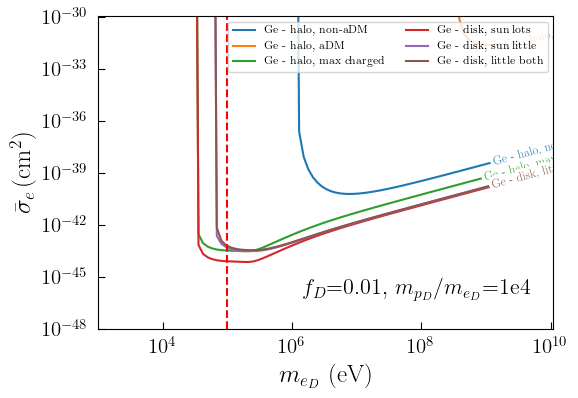

In [13]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Monotonicity Sanity Check - halo

In [65]:
["{}".format(str(x)) for x in (1,2,3)]

['1', '2', '3']

In [4]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(n)) for n in np.linspace(1,4,8)]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**n,"vesckms":500,"vekms":240,"vdist":"halo","fD":0.01} for n in np.linspace(1,4,8)]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child9), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 9.423939826071838e-38, 'v0 = 1.0'),
 Text(9000000100.0, 8.246765293518031e-38, 'v0 = 1.4285714285714286'),
 Text(9000000100.0, 4.6480871808712873e-38, 'v0 = 1.8571428571428572'),
 Text(9000000100.0, 2.096666325939175e-38, 'v0 = 2.2857142857142856'),
 Text(9000000100.0, 1.8234955968790165e-38, 'v0 = 2.7142857142857144'),
 Text(9000000100.0, 1.7923636931653433e-38, 'v0 = 3.142857142857143'),
 Text(9000000100.0, 1.7881670739040507e-38, 'v0 = 3.571428571428571'),
 Text(9000000100.0, 1.7875864288180284e-38, 'v0 = 4.0')]

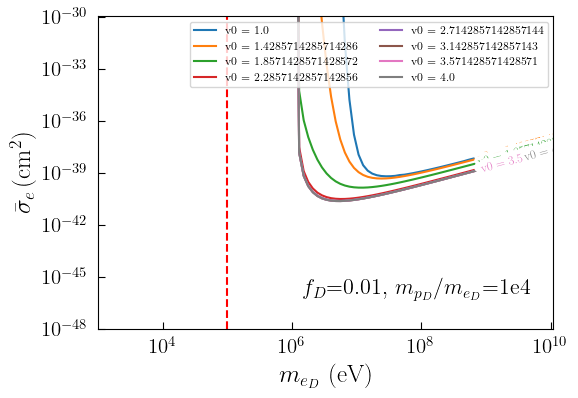

In [5]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,np.abs(lim_massless[i]),label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Monotonicity Sanity Check - disk

In [10]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(n)) for n in np.linspace(1,4,8)]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**n,"vesckms":1.1 * 10**n,"vekms":2 * 10**n,"vdist":"disk","fD":0.01} for n in np.linspace(1,4,8)]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child9), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 0.9999999999999837, 'v0 = 1.0'),
 Text(9000000100.0, 6.319768822579087e-31, 'v0 = 1.4285714285714286'),
 Text(9000000100.0, 1.849193672145359e-35, 'v0 = 1.8571428571428572'),
 Text(9000000100.0, 3.1177636742746642e-37, 'v0 = 2.2857142857142856'),
 Text(9000000100.0, 2.1783811454991664e-38, 'v0 = 2.7142857142857144'),
 Text(9000000100.0, 5.668449910183331e-39, 'v0 = 3.142857142857143'),
 Text(9000000100.0, 2.2689298206149768e-39, 'v0 = 3.571428571428571'),
 Text(9000000100.0, 3.145877938723483e-39, 'v0 = 4.0')]

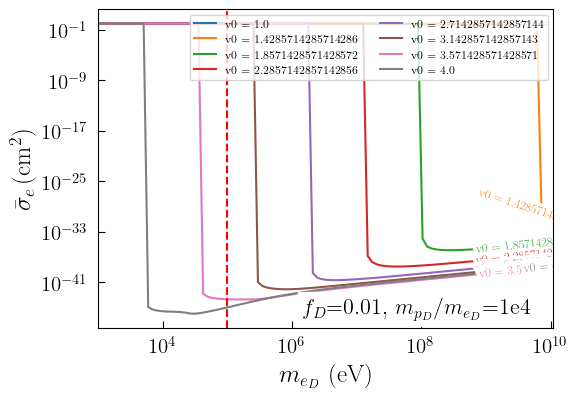

In [11]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,np.abs(lim_massless[i]),label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
# axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# V scan look for dependencies

In [14]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child7), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 3.117011057619767e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 9.124290737612587e-32, 'Ge - halo, aDM'),
 Text(9000000100.0, 5.315111757656385e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.2779058666495736e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.4263038576053844e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.4676646158680774e-39, 'Ge - disk, little both')]

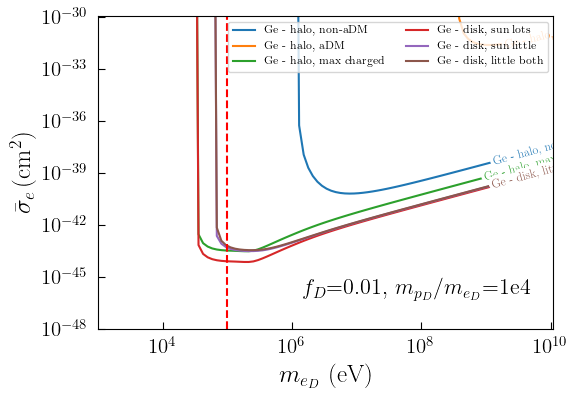

In [15]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Plot v dists

In [62]:
testlist = [1,2,3]
testlist.insert(0,4)
testlist

[4, 1, 2, 3]

In [80]:
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[1]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[1]))



Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

[Text(4.0, 0.0, 'Ge - halo, non-aDM'),
 Text(100.0, 0.0006367508784612113, 'Ge - halo, aDM'),
 Text(20.0, 0.0, 'Ge - halo, max charged'),
 Text(8.0, 0.0, 'Ge - disk, sun lots'),
 Text(1.5, 0.0, 'Ge - disk, sun little'),
 Text(10.0, 0.0, 'Ge - disk, little both')]

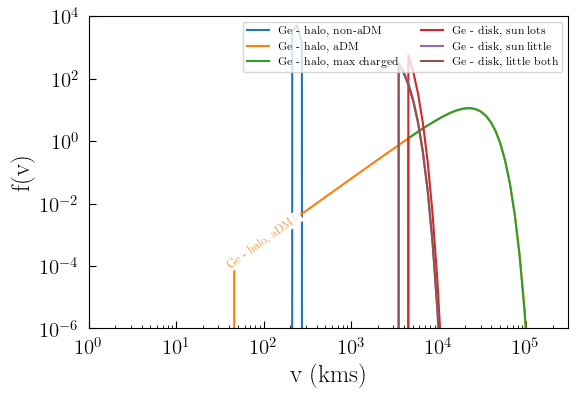

In [72]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(flist)):
    axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-6,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel("f(v)",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 0.0, 'Ge - halo, non-aDM'),
 Text(100.0, 15.376025537105576, 'Ge - halo, aDM'),
 Text(20.0, 14.852594145241499, 'Ge - halo, max charged'),
 Text(8.0, 61.77544045559996, 'Ge - disk, sun lots'),
 Text(1.5, 79.49277523439821, 'Ge - disk, sun little'),
 Text(10.0, 81.26625771495684, 'Ge - disk, little both')]

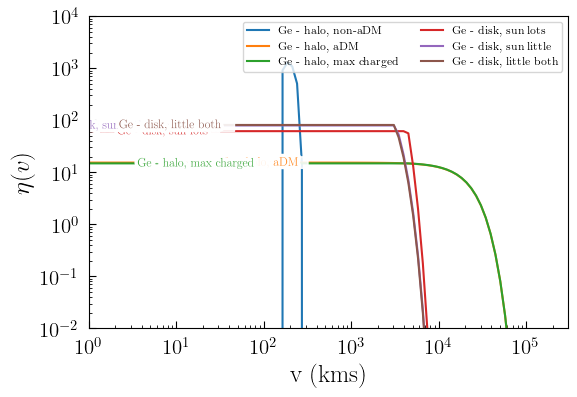

In [86]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(etalist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 0.0, 'Ge - halo, non-aDM'),
 Text(100.0, 15.376025537105566, 'Ge - halo, aDM'),
 Text(20.0, 14.852594145241452, 'Ge - halo, max charged')]

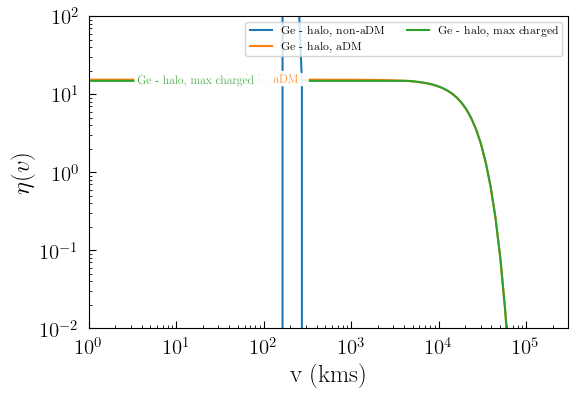

In [88]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(3):#len(flist)):
#     axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
for i in range(3):#len(flist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    

axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e2])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

it seems like the distributions for the halo case are not being given the bump that we expect them to be. Maybe its because the bump is proportional to the ratio of vesc / v0, so for the halo case you don't get a large enhancement. If that's true though, then why is there a difference between the maxed charge case and the not max charged case at all? If \eta is the only way the distribution is feeding in they should look identical.

In [73]:
lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 

Ge
Ge
Ge
Ge
Ge
Ge


In [91]:
print(lim_massless[1])

print(lim_massless[2])

[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.000000

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child7), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 3.117011057619767e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 9.124290737612437e-32, 'Ge - halo, aDM'),
 Text(9000000100.0, 5.31511175765633e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.2779058666495449e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.4263038576053757e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.4676646158680446e-39, 'Ge - disk, little both')]

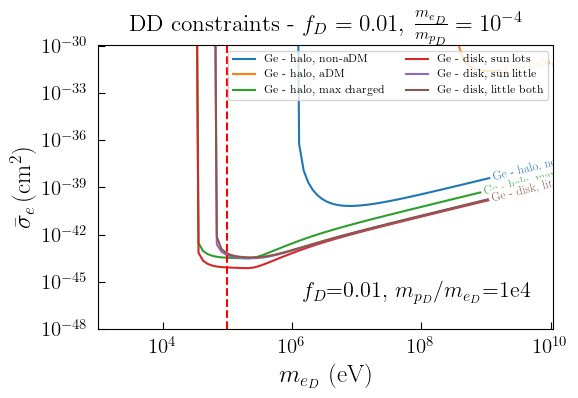

In [74]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Scan over mass ratio

In [ ]:
asslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(n)) for n in np.linspace(1,4,8)]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**n,"vesckms":1.1 * 10**n,"vekms":2 * 10**n,"vdist":"disk","fD":0.01} for n in np.linspace(1,4,8)]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

# Ve to 0

In [3]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/R

In [4]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 220,"vesckms":500,"vekms":240,"vdist":"halo","fD":0.01},\
        #    {"v0kms":sqrtmrat * 20,"vesckms":11,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
             {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":0,"vdist":"disk","fD":0.01}] # all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti